# Anhedonic AI — Full Neuron Analysis
Complete comparison of all outputs: Original (Phase 1), ASDiv (Phase 3), and MMLU (Phase 5)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

NUM_LAYERS = 28
K_THRESHOLDS = [27, 30, 35, 40, 45, 50, 54]

SUBJECTS = [
    'abstract_algebra','anatomy','astronomy','business_ethics',
    'clinical_knowledge','college_biology','college_computer_science',
    'college_mathematics','college_medicine','computer_security',
    'conceptual_physics','econometrics','electrical_engineering',
    'elementary_mathematics','formal_logic','global_facts',
    'high_school_biology','high_school_chemistry','high_school_computer_science',
    'high_school_european_history','high_school_geography',
    'high_school_government_and_politics','high_school_macroeconomics',
    'high_school_mathematics','high_school_microeconomics','high_school_physics',
    'high_school_psychology','high_school_statistics','high_school_us_history',
    'high_school_world_history','human_aging','human_sexuality',
    'international_law','jurisprudence','logical_fallacies','machine_learning',
    'management','marketing','medical_genetics','miscellaneous','moral_disputes',
    'moral_scenarios','nutrition','philosophy','prehistory',
    'professional_accounting','professional_law','professional_medicine',
    'professional_psychology','public_relations','security_studies','sociology',
    'virology','world_religions'
]

# ── Paths ──────────────────────────────────────────────────────────────────
BASE     = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1'
ORIG_DIR = f'{BASE}/phase4/extraction'
ASDIV_DIR= f'{BASE}/evaluation/ASDiv/extraction'
MMLU_DIR = f'{BASE}/evaluation/mmlu/neurons/mmlu'

print('Paths set.')

Paths set.


## 1 — Load all neuron sets

In [3]:
def load_set(path):
    df = pd.read_csv(path)
    return set(zip(df['layer'].tolist(), df['neuron'].tolist()))

def layer_dist(neuron_set):
    counts = defaultdict(int)
    for (l, _) in neuron_set:
        counts[l] += 1
    return [counts.get(l, 0) for l in range(NUM_LAYERS)]

# Original
orig_reward = load_set(f'{ORIG_DIR}/universal_reward_neurons.csv')
orig_money  = load_set(f'{ORIG_DIR}/universal_money_neurons.csv')
orig_core   = load_set(f'{ORIG_DIR}/master_incentive_core.csv')

# ASDiv
asdiv_reward = load_set(f'{ASDIV_DIR}/asdiv_universal_reward_neurons.csv')
asdiv_money  = load_set(f'{ASDIV_DIR}/asdiv_universal_money_neurons.csv')
asdiv_core   = load_set(f'{ASDIV_DIR}/asdiv_master_incentive_core.csv')

# MMLU per-subject
mmlu_per_subject = {}
for subj in SUBJECTS:
    mmlu_per_subject[subj] = {
        'reward': load_set(f'{MMLU_DIR}/per_subject/{subj}/reward.csv'),
        'money':  load_set(f'{MMLU_DIR}/per_subject/{subj}/money.csv'),
        'core':   load_set(f'{MMLU_DIR}/per_subject/{subj}/core.csv'),
    }

# MMLU cross-subject
mmlu_k = {k: load_set(f'{MMLU_DIR}/cross_subject/k{k}.csv') for k in K_THRESHOLDS}
subject_counts_df = pd.read_csv(f'{MMLU_DIR}/cross_subject/subject_counts.csv')

# Key derived sets
shared_163 = mmlu_k[54] & asdiv_core
triple_29  = mmlu_k[54] & asdiv_core & orig_core

print(f'Orig   — reward: {len(orig_reward):>5}, money: {len(orig_money):>5}, core: {len(orig_core):>5}')
print(f'ASDiv  — reward: {len(asdiv_reward):>5}, money: {len(asdiv_money):>5}, core: {len(asdiv_core):>5}')
print(f'MMLU per-subject loaded: {len(mmlu_per_subject)} subjects')
print(f'MMLU K thresholds: {list(mmlu_k.keys())}')
print(f'Shared 163 (MMLU K=54 ∩ ASDiv):         {len(shared_163)}')
print(f'Triple 29  (MMLU K=54 ∩ ASDiv ∩ Orig):  {len(triple_29)}')

Orig   — reward:  5558, money:  5467, core:  3528
ASDiv  — reward: 11517, money: 12302, core:  7913
MMLU per-subject loaded: 54 subjects
MMLU K thresholds: [27, 30, 35, 40, 45, 50, 54]
Shared 163 (MMLU K=54 ∩ ASDiv):         163
Triple 29  (MMLU K=54 ∩ ASDiv ∩ Orig):  29


## 2 — Set sizes overview

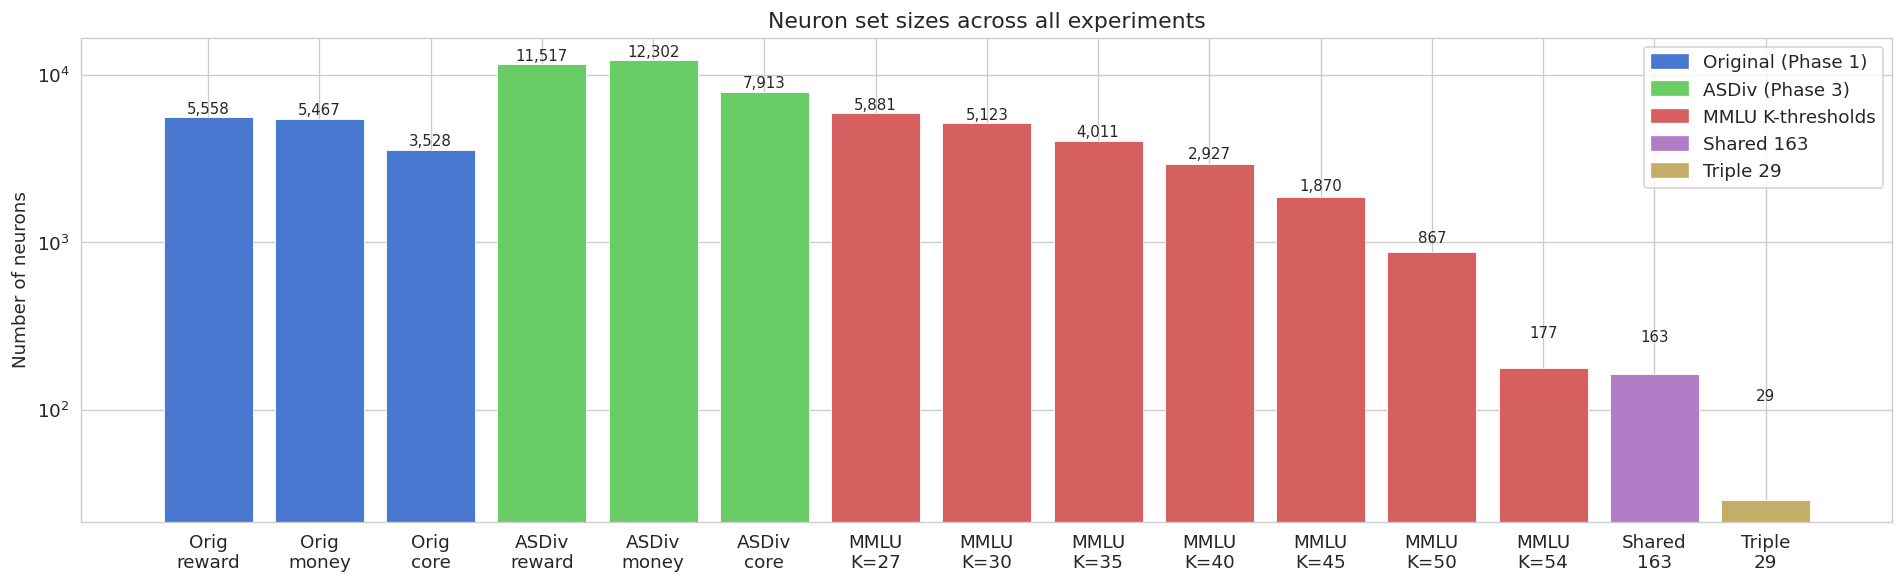

In [5]:
labels = [
    'Orig\nreward', 'Orig\nmoney', 'Orig\ncore',
    'ASDiv\nreward', 'ASDiv\nmoney', 'ASDiv\ncore',
    'MMLU\nK=27', 'MMLU\nK=30', 'MMLU\nK=35', 'MMLU\nK=40',
    'MMLU\nK=45', 'MMLU\nK=50', 'MMLU\nK=54',
    'Shared\n163', 'Triple\n29'
]
sizes = [
    len(orig_reward), len(orig_money), len(orig_core),
    len(asdiv_reward), len(asdiv_money), len(asdiv_core),
    *[len(mmlu_k[k]) for k in K_THRESHOLDS],
    len(shared_163), len(triple_29)
]
colors = (['#4878CF']*3 + ['#6ACC65']*3 + ['#D65F5F']*7 + ['#B47CC7', '#C4AD66'])

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(labels, sizes, color=colors, edgecolor='white', linewidth=0.5)
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{size:,}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Number of neurons')
ax.set_title('Neuron set sizes across all experiments')
ax.set_yscale('log')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#4878CF', label='Original (Phase 1)'),
    Patch(color='#6ACC65', label='ASDiv (Phase 3)'),
    Patch(color='#D65F5F', label='MMLU K-thresholds'),
    Patch(color='#B47CC7', label='Shared 163'),
    Patch(color='#C4AD66', label='Triple 29'),
])
plt.tight_layout()
plt.show()

## 3 — MMLU subject count distribution

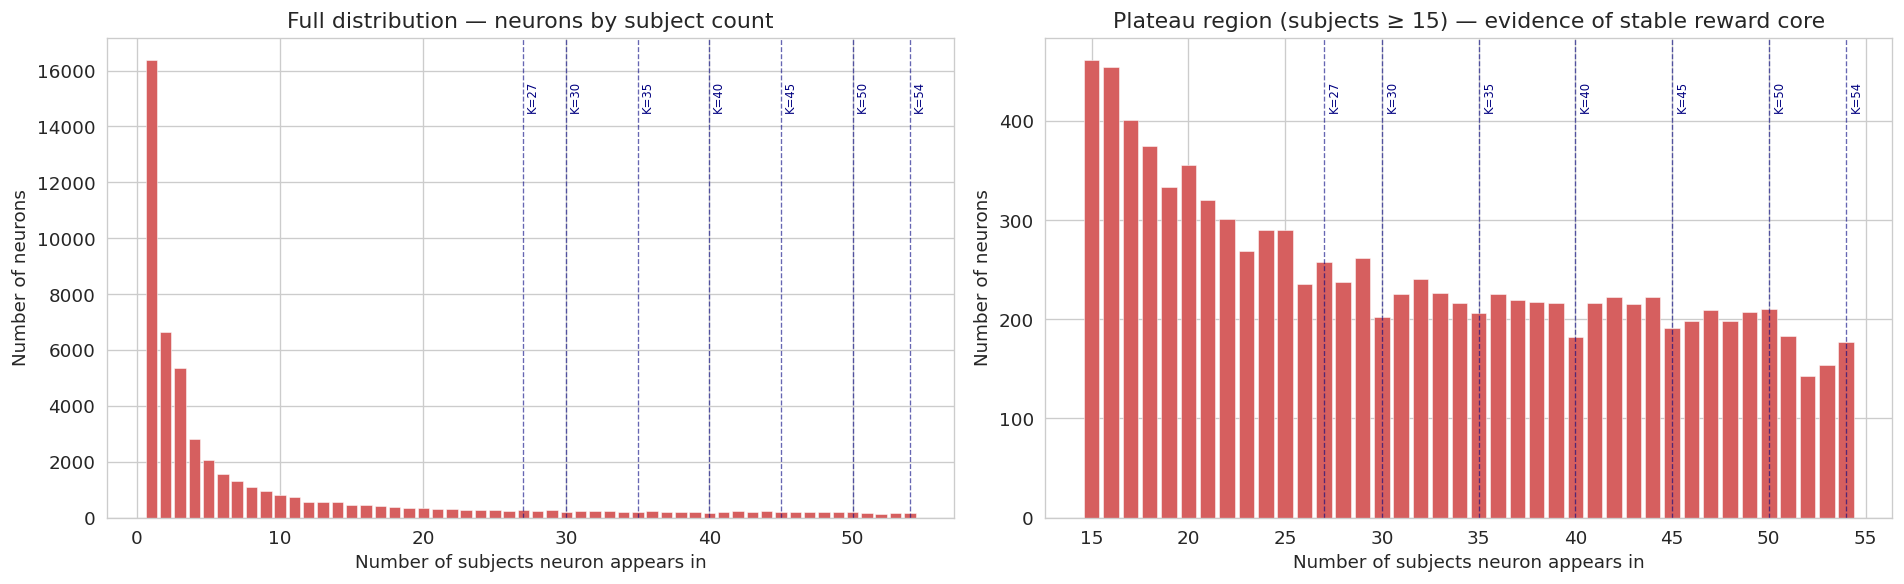

Neurons appearing in ALL 54 subjects: 177
Neurons appearing in ≥50 subjects:   867
Neurons appearing in ≥27 subjects:   5881


In [6]:
dist = subject_counts_df['subject_count'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full distribution
axes[0].bar(dist.index, dist.values, color='#D65F5F', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Number of subjects neuron appears in')
axes[0].set_ylabel('Number of neurons')
axes[0].set_title('Full distribution — neurons by subject count')
for k in K_THRESHOLDS:
    axes[0].axvline(k, color='navy', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[0].text(k+0.2, axes[0].get_ylim()[1]*0.85, f'K={k}', fontsize=7, color='navy', rotation=90)

# Zoomed: subjects 15-54 to show the plateau
plateau = dist[dist.index >= 15]
axes[1].bar(plateau.index, plateau.values, color='#D65F5F', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Number of subjects neuron appears in')
axes[1].set_ylabel('Number of neurons')
axes[1].set_title('Plateau region (subjects ≥ 15) — evidence of stable reward core')
for k in K_THRESHOLDS:
    if k >= 15:
        axes[1].axvline(k, color='navy', linestyle='--', linewidth=0.8, alpha=0.6)
        axes[1].text(k+0.2, axes[1].get_ylim()[1]*0.85, f'K={k}', fontsize=7, color='navy', rotation=90)

plt.tight_layout()
plt.show()

print(f'Neurons appearing in ALL 54 subjects: {dist.get(54, 0)}')
print(f'Neurons appearing in ≥50 subjects:   {dist[dist.index >= 50].sum()}')
print(f'Neurons appearing in ≥27 subjects:   {dist[dist.index >= 27].sum()}')

## 4 — Layer distributions: Orig, ASDiv, MMLU

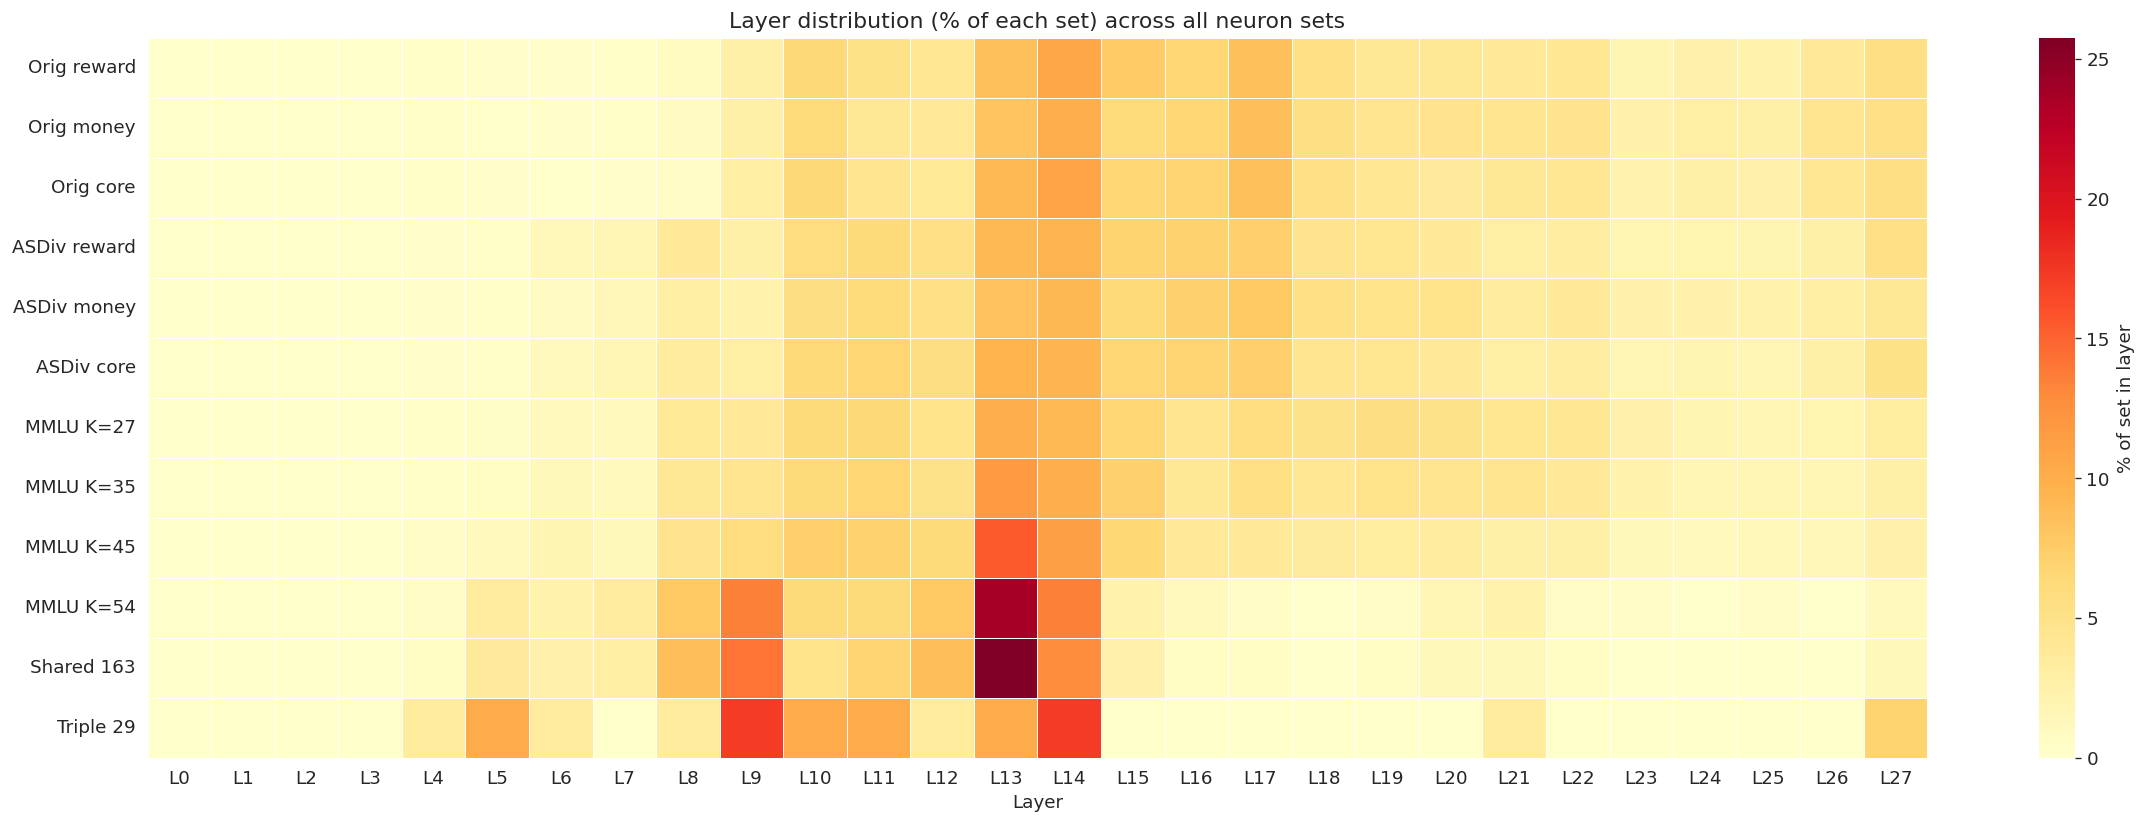

In [7]:
layers = list(range(NUM_LAYERS))

# Build matrix: rows = neuron sets, cols = layers
sets_ordered = {
    'Orig reward':    orig_reward,
    'Orig money':     orig_money,
    'Orig core':      orig_core,
    'ASDiv reward':   asdiv_reward,
    'ASDiv money':    asdiv_money,
    'ASDiv core':     asdiv_core,
    'MMLU K=27':      mmlu_k[27],
    'MMLU K=35':      mmlu_k[35],
    'MMLU K=45':      mmlu_k[45],
    'MMLU K=54':      mmlu_k[54],
    'Shared 163':     shared_163,
    'Triple 29':      triple_29,
}

# Normalize by set size (% of each set per layer)
matrix_pct = []
for name, s in sets_ordered.items():
    dist = layer_dist(s)
    total = len(s) if s else 1
    matrix_pct.append([c / total * 100 for c in dist])

df_heatmap = pd.DataFrame(matrix_pct,
                           index=list(sets_ordered.keys()),
                           columns=[f'L{l}' for l in layers])

fig, ax = plt.subplots(figsize=(20, 7))
sns.heatmap(df_heatmap, ax=ax, cmap='YlOrRd', annot=False,
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': '% of set in layer'})
ax.set_title('Layer distribution (% of each set) across all neuron sets')
ax.set_xlabel('Layer')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 5 — Layer distributions: absolute counts side by side

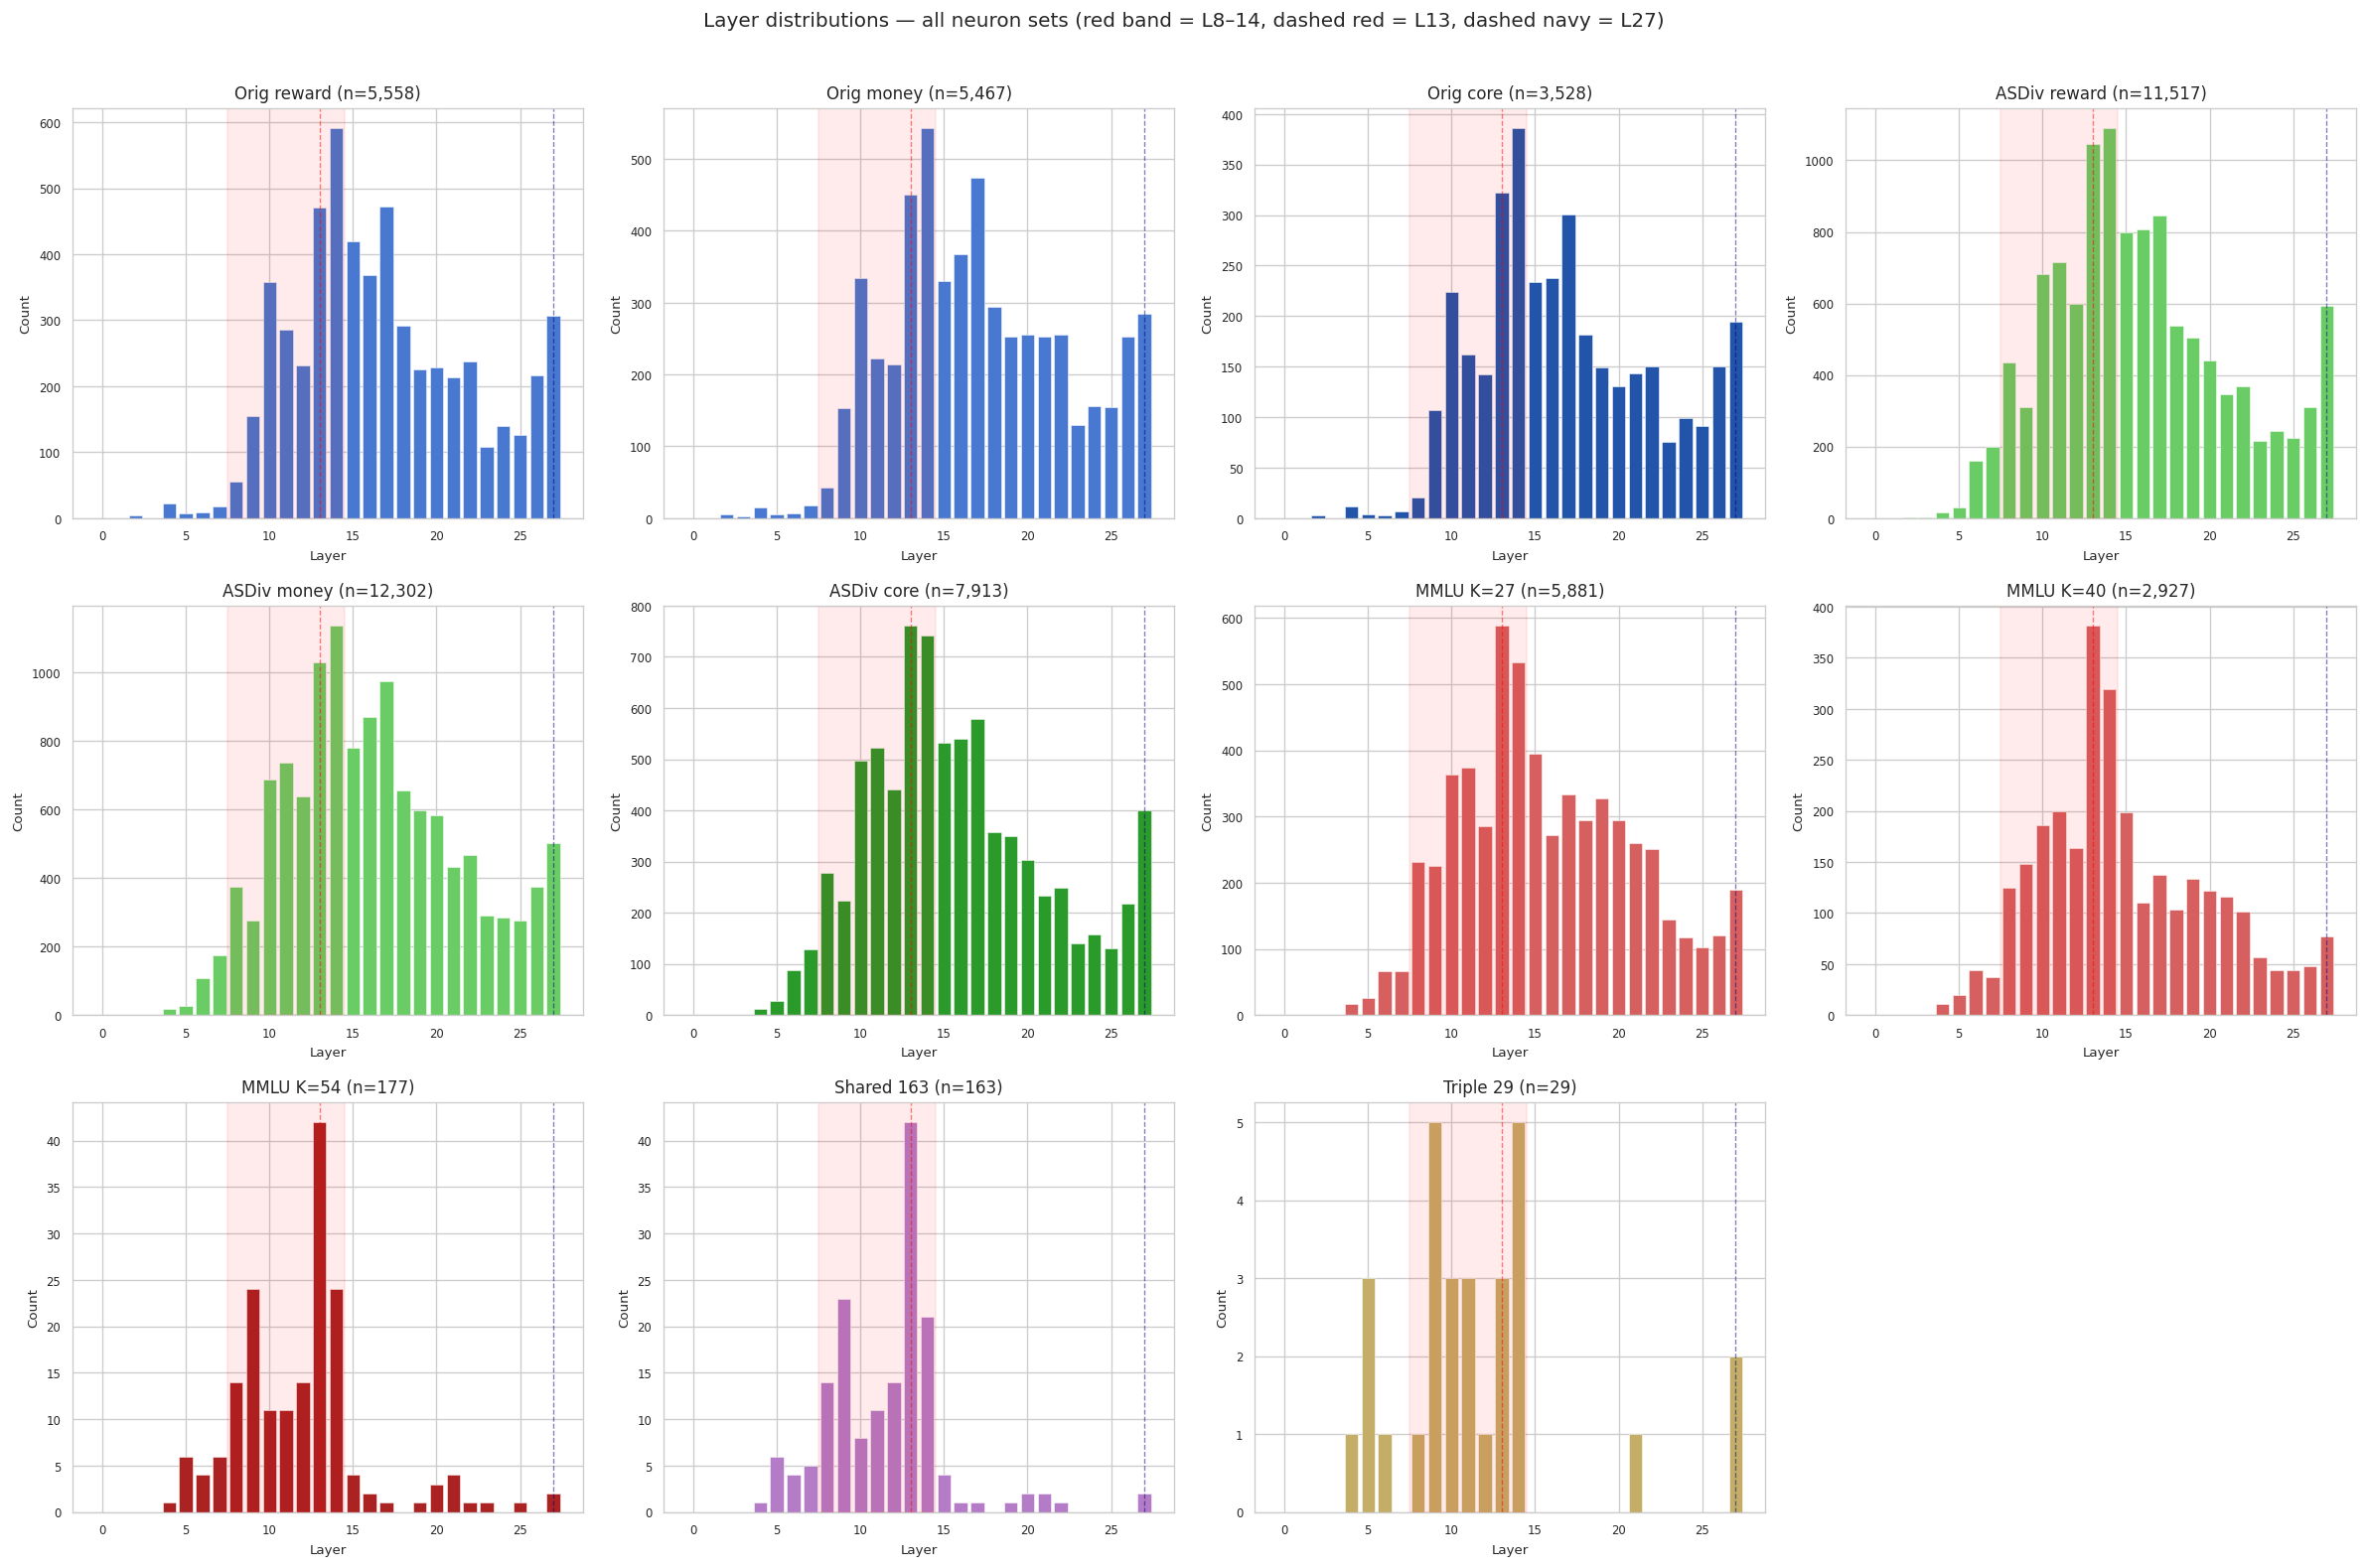

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(20, 13), sharey=False)
axes = axes.flatten()

plot_sets = {
    'Orig reward':    (orig_reward, '#4878CF'),
    'Orig money':     (orig_money,  '#4878CF'),
    'Orig core':      (orig_core,   '#2255AA'),
    'ASDiv reward':   (asdiv_reward,'#6ACC65'),
    'ASDiv money':    (asdiv_money, '#6ACC65'),
    'ASDiv core':     (asdiv_core,  '#2A9A2A'),
    'MMLU K=27':      (mmlu_k[27],  '#D65F5F'),
    'MMLU K=40':      (mmlu_k[40],  '#D65F5F'),
    'MMLU K=54':      (mmlu_k[54],  '#AA2222'),
    'Shared 163':     (shared_163,  '#B47CC7'),
    'Triple 29':      (triple_29,   '#C4AD66'),
}

for ax, (name, (s, color)) in zip(axes, plot_sets.items()):
    dist = layer_dist(s)
    ax.bar(layers, dist, color=color, edgecolor='white', linewidth=0.3)
    ax.set_title(f'{name} (n={len(s):,})', fontsize=10)
    ax.set_xlabel('Layer', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.axvspan(7.5, 14.5, alpha=0.08, color='red', label='L8–14')
    ax.axvline(13, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(27, color='navy', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(labelsize=7)

for ax in axes[len(plot_sets):]:
    ax.set_visible(False)

fig.suptitle('Layer distributions — all neuron sets (red band = L8–14, dashed red = L13, dashed navy = L27)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6 — Pairwise Jaccard similarity matrix

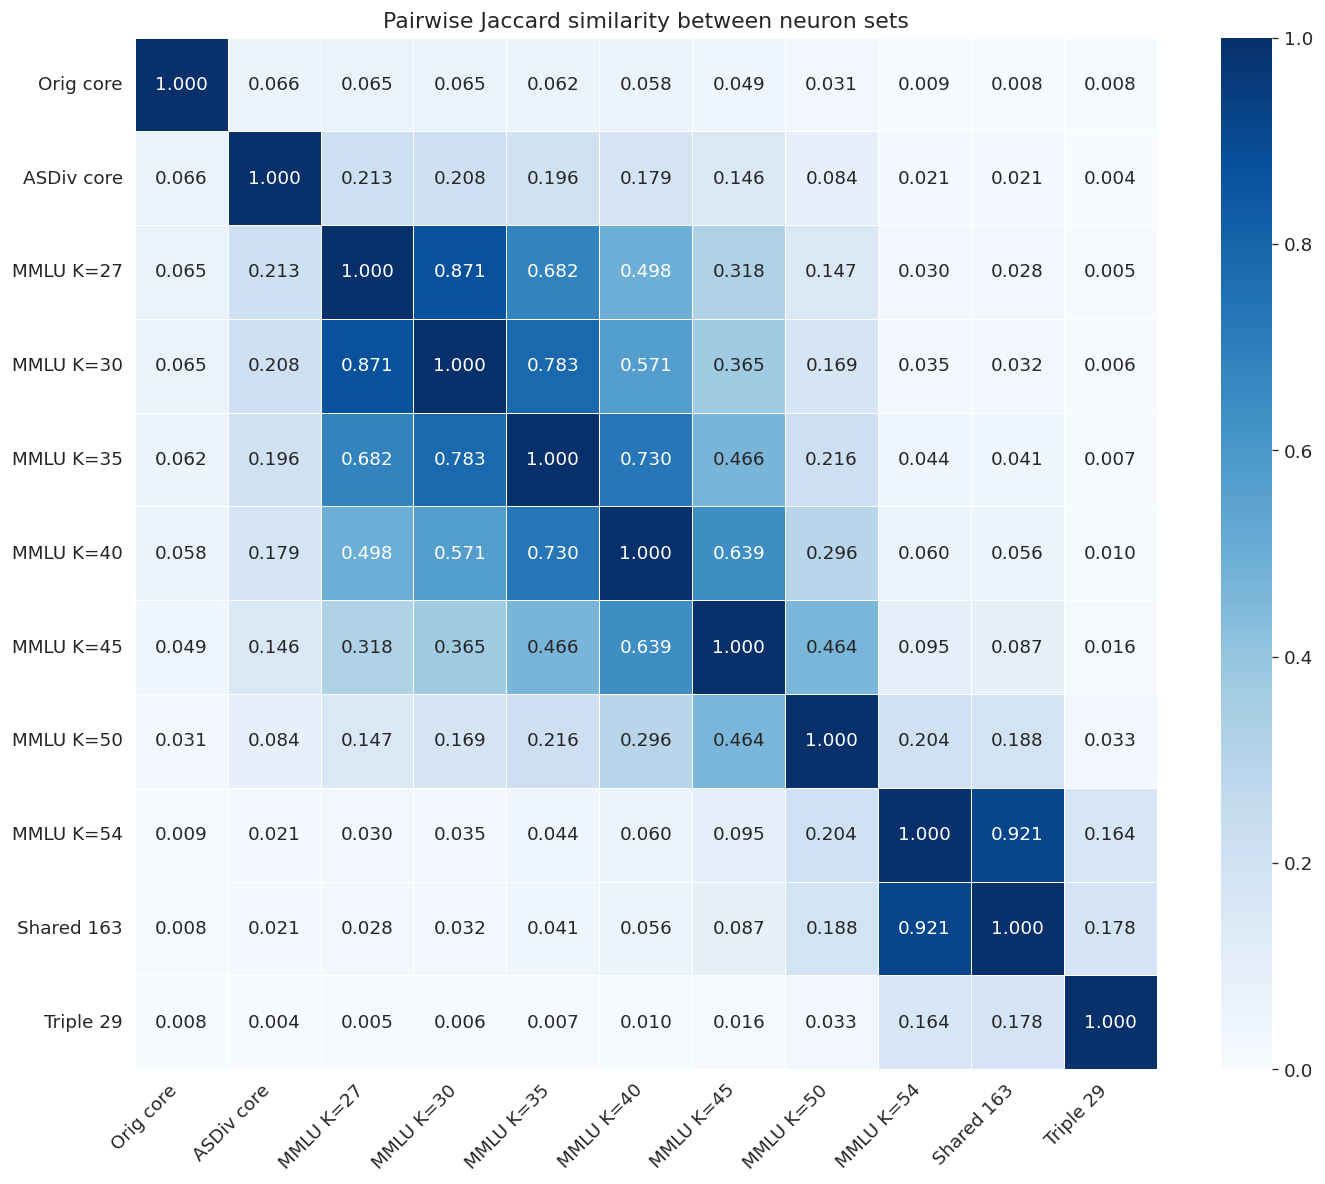

In [9]:
jaccard_sets = {
    'Orig core':   orig_core,
    'ASDiv core':  asdiv_core,
    'MMLU K=27':   mmlu_k[27],
    'MMLU K=30':   mmlu_k[30],
    'MMLU K=35':   mmlu_k[35],
    'MMLU K=40':   mmlu_k[40],
    'MMLU K=45':   mmlu_k[45],
    'MMLU K=50':   mmlu_k[50],
    'MMLU K=54':   mmlu_k[54],
    'Shared 163':  shared_163,
    'Triple 29':   triple_29,
}

names = list(jaccard_sets.keys())
n = len(names)
jmat = np.zeros((n, n))

for i, (na, sa) in enumerate(jaccard_sets.items()):
    for j, (nb, sb) in enumerate(jaccard_sets.items()):
        u = len(sa | sb)
        jmat[i, j] = len(sa & sb) / u if u else 0.0

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(jmat, ax=ax, annot=True, fmt='.3f',
            xticklabels=names, yticklabels=names,
            cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, linecolor='white')
ax.set_title('Pairwise Jaccard similarity between neuron sets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7 — MMLU per-subject core sizes

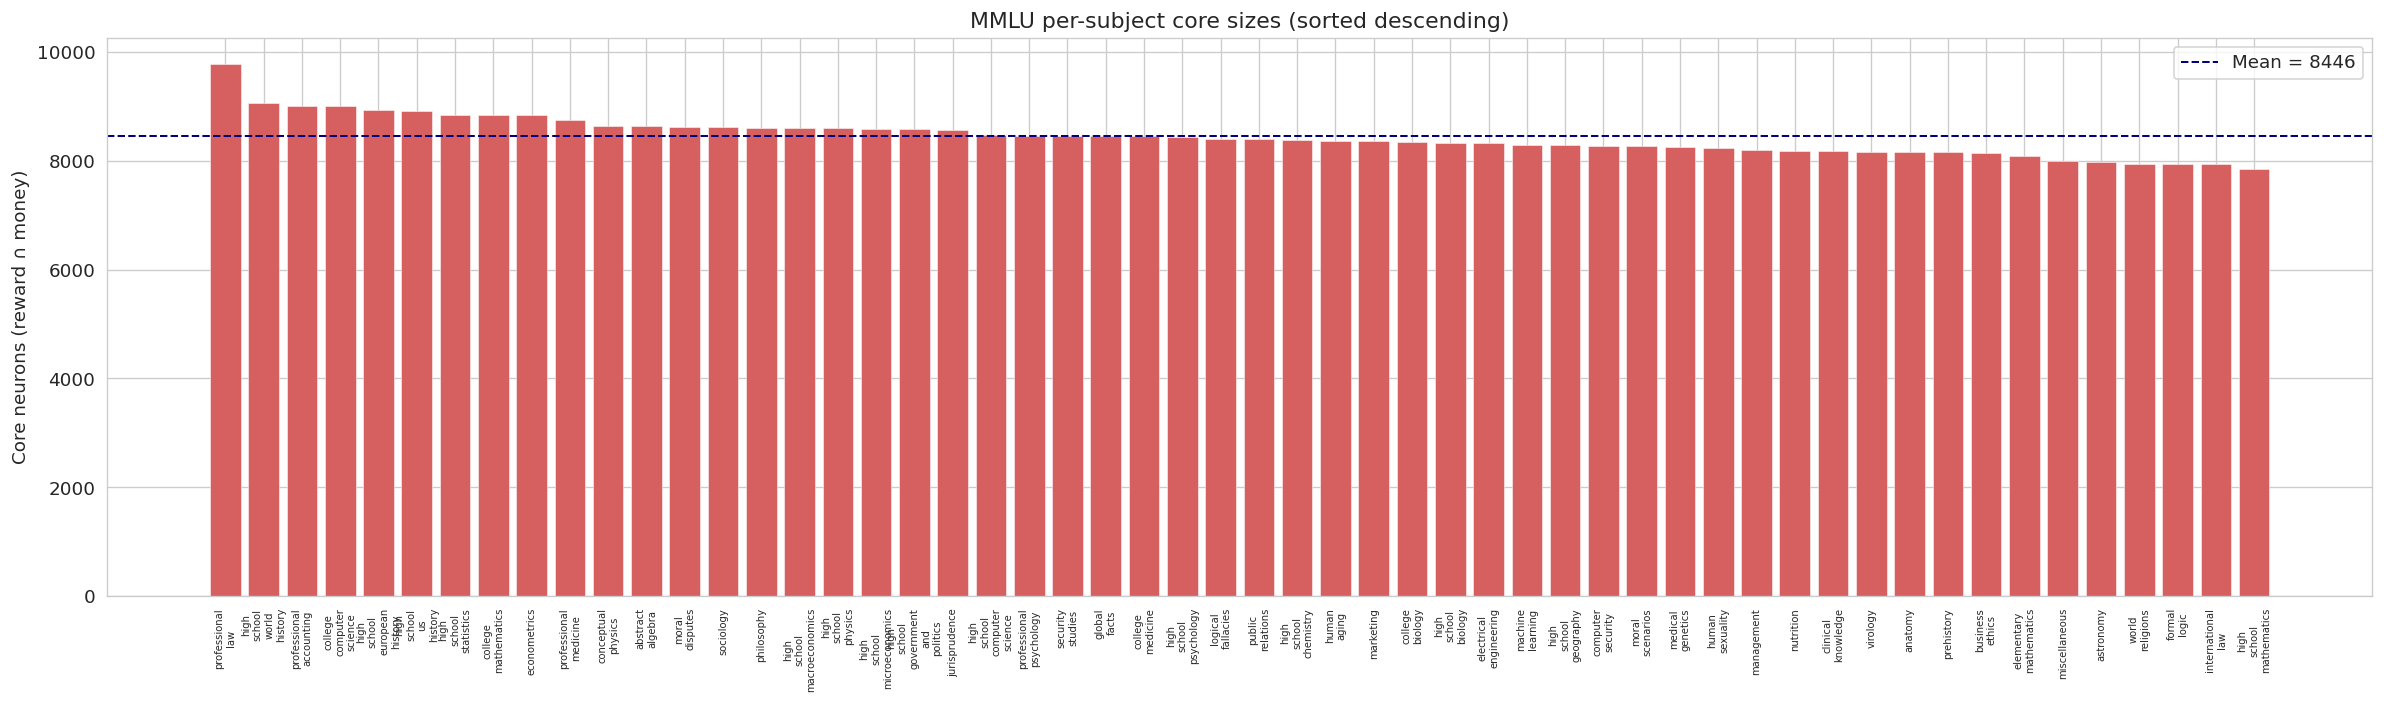

Mean core size:   8446
Std:              347
Min (high_school_mathematics): 7854
Max (professional_law):  9774


In [10]:
subj_core_sizes = {s: len(mmlu_per_subject[s]['core']) for s in SUBJECTS}
subj_reward_sizes = {s: len(mmlu_per_subject[s]['reward']) for s in SUBJECTS}
subj_money_sizes  = {s: len(mmlu_per_subject[s]['money'])  for s in SUBJECTS}

sorted_subjects = sorted(subj_core_sizes.items(), key=lambda x: -x[1])
s_labels = [s[0].replace('_', '\n') for s in sorted_subjects]
s_cores  = [s[1] for s in sorted_subjects]

fig, ax = plt.subplots(figsize=(20, 6))
bars = ax.bar(range(len(s_labels)), s_cores, color='#D65F5F', edgecolor='white', linewidth=0.3)
ax.axhline(np.mean(s_cores), color='navy', linestyle='--', linewidth=1.2, label=f'Mean = {np.mean(s_cores):.0f}')
ax.set_xticks(range(len(s_labels)))
ax.set_xticklabels(s_labels, fontsize=6, rotation=90)
ax.set_ylabel('Core neurons (reward ∩ money)')
ax.set_title('MMLU per-subject core sizes (sorted descending)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean core size:   {np.mean(s_cores):.0f}')
print(f'Std:              {np.std(s_cores):.0f}')
print(f'Min ({sorted_subjects[-1][0]}): {sorted_subjects[-1][1]}')
print(f'Max ({sorted_subjects[0][0]}):  {sorted_subjects[0][1]}')

## 8 — Layer 13 deep dive

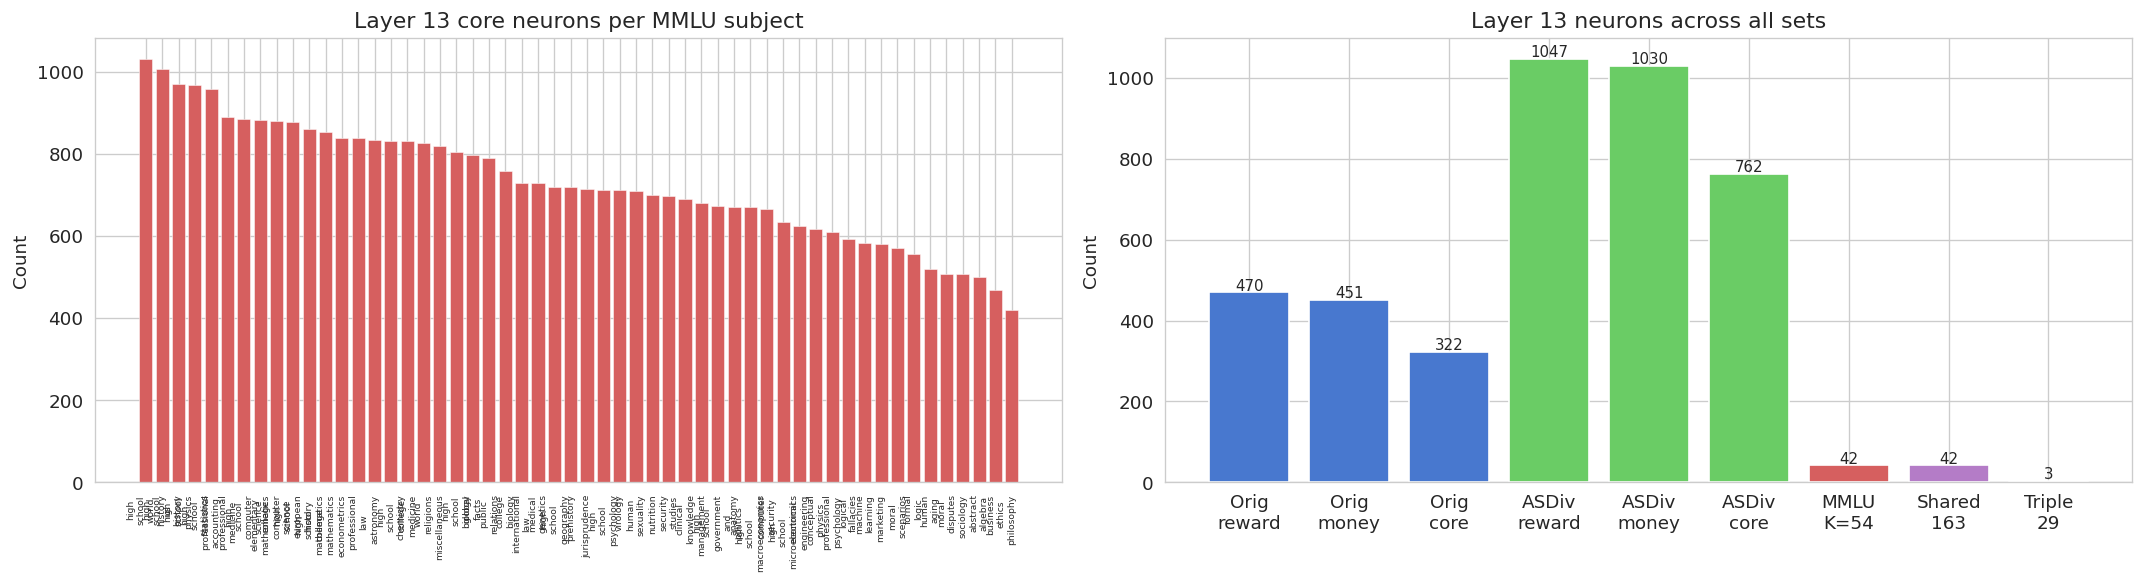

In [11]:
def l_neurons(s, layer):
    return {n for (l, n) in s if l == layer}

# Layer 13 counts per subject
l13_per_subj = {s: len(l_neurons(mmlu_per_subject[s]['core'], 13)) for s in SUBJECTS}
sorted_l13 = sorted(l13_per_subj.items(), key=lambda x: -x[1])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Per-subject layer 13 counts
axes[0].bar(range(len(sorted_l13)),
            [x[1] for x in sorted_l13],
            color='#D65F5F', edgecolor='white', linewidth=0.3)
axes[0].set_xticks(range(len(sorted_l13)))
axes[0].set_xticklabels([x[0].replace('_','\n') for x in sorted_l13], fontsize=5.5, rotation=90)
axes[0].set_title('Layer 13 core neurons per MMLU subject')
axes[0].set_ylabel('Count')

# Layer 13 across all sets
l13_sizes = {
    'Orig\nreward':   len(l_neurons(orig_reward, 13)),
    'Orig\nmoney':    len(l_neurons(orig_money,  13)),
    'Orig\ncore':     len(l_neurons(orig_core,   13)),
    'ASDiv\nreward':  len(l_neurons(asdiv_reward,13)),
    'ASDiv\nmoney':   len(l_neurons(asdiv_money, 13)),
    'ASDiv\ncore':    len(l_neurons(asdiv_core,  13)),
    'MMLU\nK=54':     len(l_neurons(mmlu_k[54],  13)),
    'Shared\n163':    len(l_neurons(shared_163,  13)),
    'Triple\n29':     len(l_neurons(triple_29,   13)),
}
colors_l13 = ['#4878CF']*3 + ['#6ACC65']*3 + ['#D65F5F','#B47CC7','#C4AD66']
axes[1].bar(l13_sizes.keys(), l13_sizes.values(), color=colors_l13, edgecolor='white')
for i, (k, v) in enumerate(l13_sizes.items()):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)
axes[1].set_title('Layer 13 neurons across all sets')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 9 — Layer 27 deep dive (Phase 4 vs MMLU discrepancy)

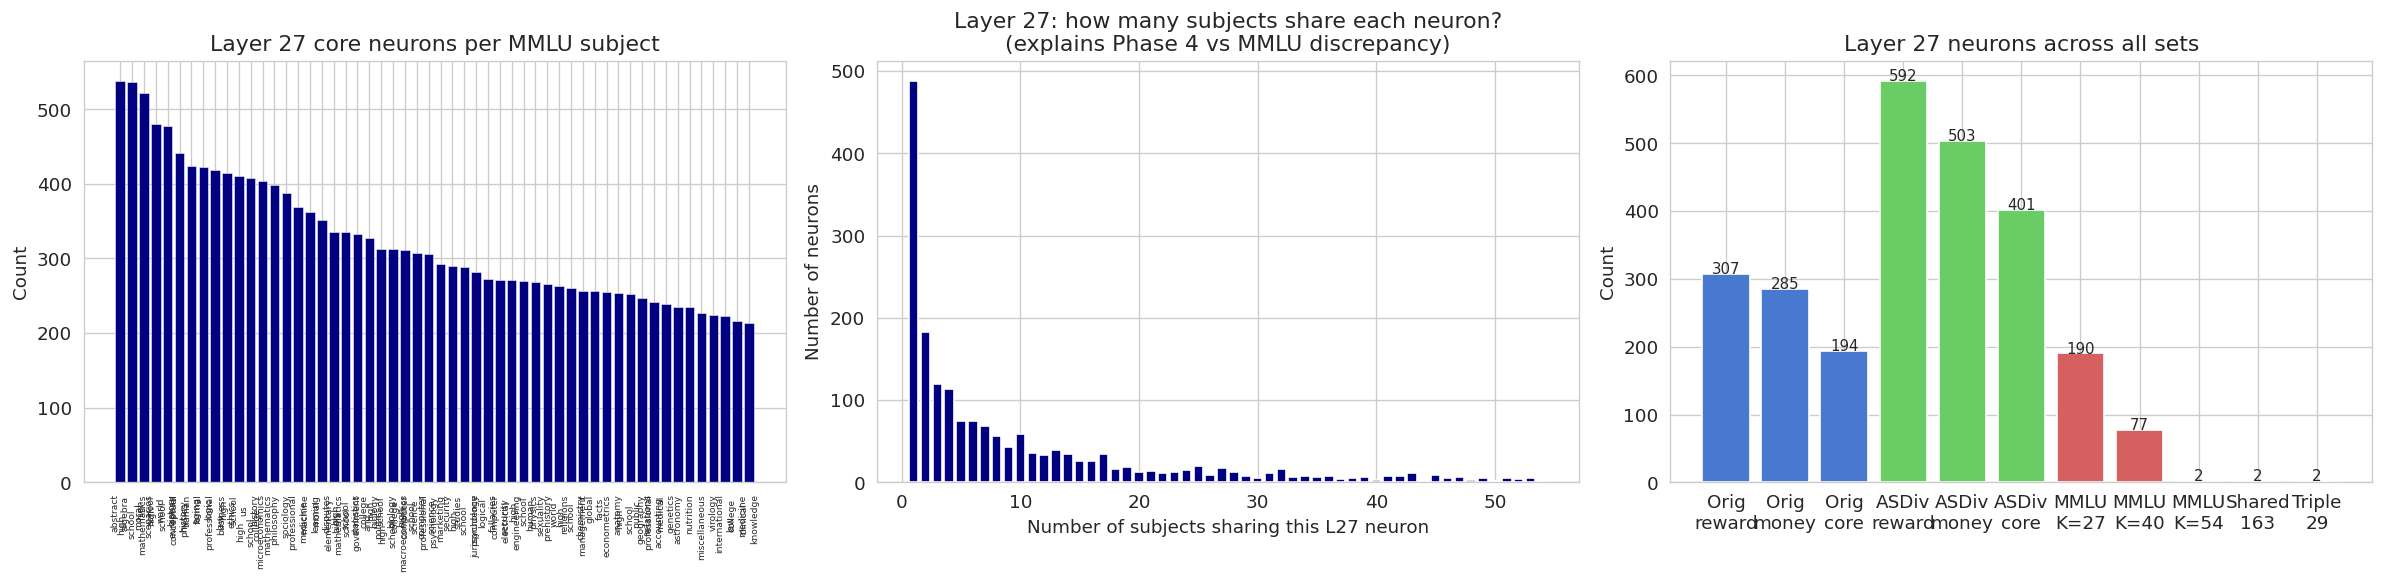

Total unique L27 neurons across all subjects: 1826
L27 neurons surviving all 54 subjects:       2
→ Layer 27 has many subject-specific neurons, not a stable abstract reward layer


In [12]:
# Layer 27 counts per subject
l27_per_subj = {s: len(l_neurons(mmlu_per_subject[s]['core'], 27)) for s in SUBJECTS}
sorted_l27 = sorted(l27_per_subj.items(), key=lambda x: -x[1])

# How many subjects share each layer-27 neuron?
l27_neuron_counts = defaultdict(int)
for s in SUBJECTS:
    for n in l_neurons(mmlu_per_subject[s]['core'], 27):
        l27_neuron_counts[n] += 1

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Per-subject L27 core sizes
axes[0].bar(range(len(sorted_l27)),
            [x[1] for x in sorted_l27],
            color='navy', edgecolor='white', linewidth=0.3)
axes[0].set_xticks(range(len(sorted_l27)))
axes[0].set_xticklabels([x[0].replace('_','\n') for x in sorted_l27], fontsize=5.5, rotation=90)
axes[0].set_title('Layer 27 core neurons per MMLU subject')
axes[0].set_ylabel('Count')

# Distribution of how many subjects share each L27 neuron
sharing_dist = defaultdict(int)
for n, cnt in l27_neuron_counts.items():
    sharing_dist[cnt] += 1
sharing_dist = dict(sorted(sharing_dist.items()))
axes[1].bar(sharing_dist.keys(), sharing_dist.values(), color='navy', edgecolor='white')
axes[1].set_xlabel('Number of subjects sharing this L27 neuron')
axes[1].set_ylabel('Number of neurons')
axes[1].set_title('Layer 27: how many subjects share each neuron?\n(explains Phase 4 vs MMLU discrepancy)')

# L27 across all sets
l27_sizes = {
    'Orig\nreward':  len(l_neurons(orig_reward, 27)),
    'Orig\nmoney':   len(l_neurons(orig_money,  27)),
    'Orig\ncore':    len(l_neurons(orig_core,   27)),
    'ASDiv\nreward': len(l_neurons(asdiv_reward,27)),
    'ASDiv\nmoney':  len(l_neurons(asdiv_money, 27)),
    'ASDiv\ncore':   len(l_neurons(asdiv_core,  27)),
    'MMLU\nK=27':    len(l_neurons(mmlu_k[27],  27)),
    'MMLU\nK=40':    len(l_neurons(mmlu_k[40],  27)),
    'MMLU\nK=54':    len(l_neurons(mmlu_k[54],  27)),
    'Shared\n163':   len(l_neurons(shared_163,  27)),
    'Triple\n29':    len(l_neurons(triple_29,   27)),
}
colors_l27 = ['#4878CF']*3 + ['#6ACC65']*3 + ['#D65F5F']*3 + ['#B47CC7','#C4AD66']
axes[2].bar(l27_sizes.keys(), l27_sizes.values(), color=colors_l27, edgecolor='white')
for i, (k, v) in enumerate(l27_sizes.items()):
    axes[2].text(i, v + 0.5, str(v), ha='center', fontsize=9)
axes[2].set_title('Layer 27 neurons across all sets')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

total_unique_l27 = len(l27_neuron_counts)
survive_all = sum(1 for cnt in l27_neuron_counts.values() if cnt == 54)
print(f'Total unique L27 neurons across all subjects: {total_unique_l27}')
print(f'L27 neurons surviving all 54 subjects:       {survive_all}')
print(f'→ Layer 27 has many subject-specific neurons, not a stable abstract reward layer')

## 10 — Recall / precision matrix (all sets vs orig and ASDiv)

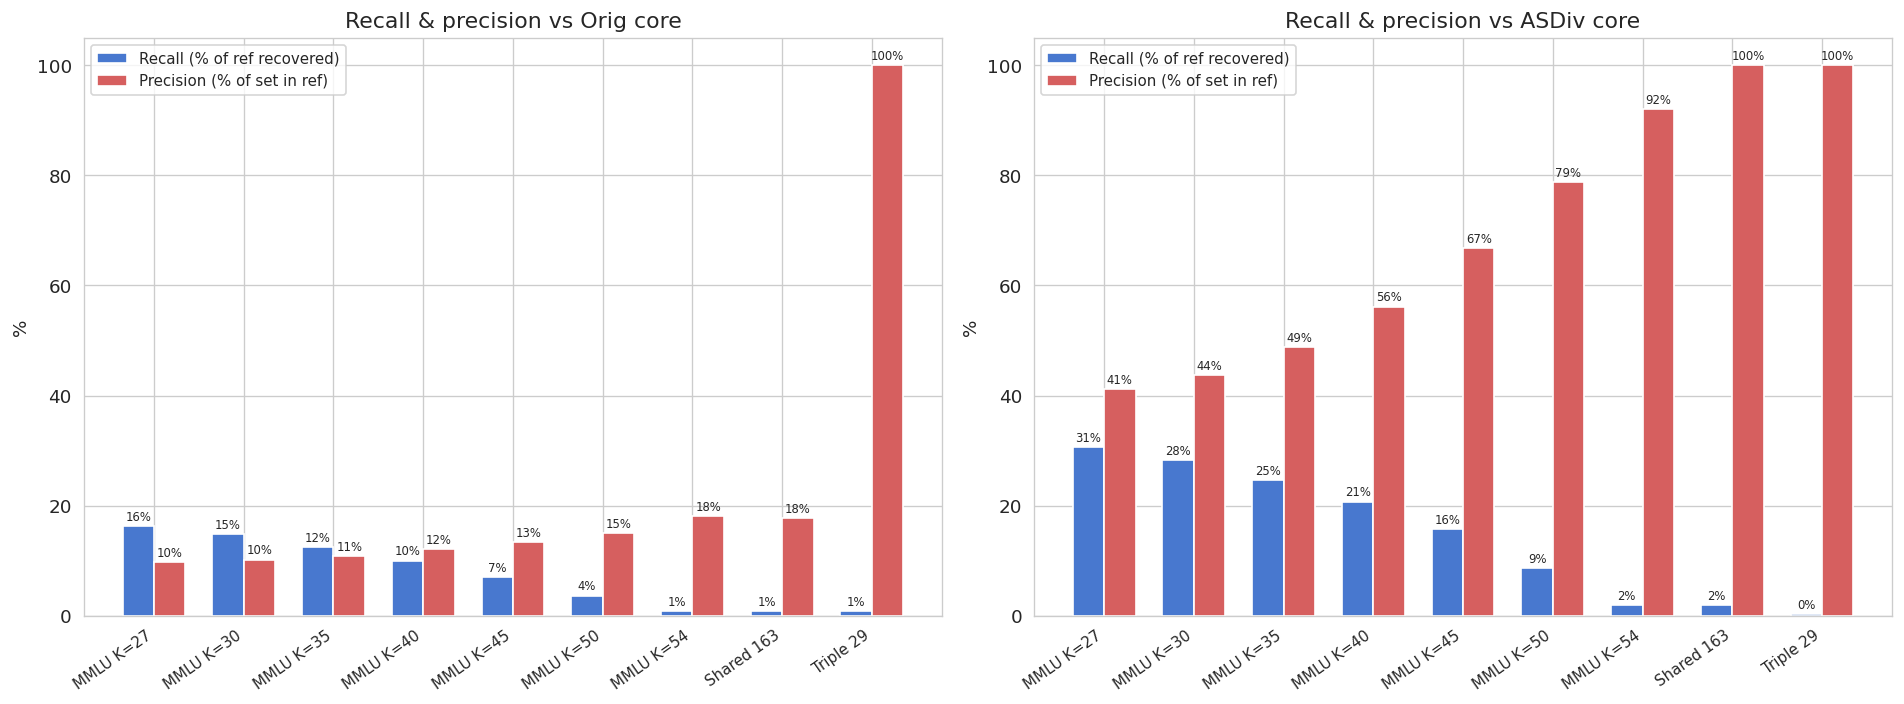

In [14]:
reference_sets = {'Orig core': orig_core, 'ASDiv core': asdiv_core}
comparison_sets = {
    'MMLU K=27': mmlu_k[27], 'MMLU K=30': mmlu_k[30],
    'MMLU K=35': mmlu_k[35], 'MMLU K=40': mmlu_k[40],
    'MMLU K=45': mmlu_k[45], 'MMLU K=50': mmlu_k[50],
    'MMLU K=54': mmlu_k[54], 'Shared 163': shared_163,
    'Triple 29': triple_29,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (ref_name, ref_set) in zip(axes, reference_sets.items()):
    recalls    = []
    precisions = []
    labels_rp  = []
    for cname, cset in comparison_sets.items():
        inter = ref_set & cset
        recall    = len(inter) / len(ref_set) * 100 if ref_set else 0
        precision = len(inter) / len(cset)    * 100 if cset    else 0
        recalls.append(recall)
        precisions.append(precision)
        labels_rp.append(cname)

    x = np.arange(len(labels_rp))
    w = 0.35
    ax.bar(x - w/2, recalls,    w, label='Recall (% of ref recovered)',    color='#4878CF', edgecolor='white')
    ax.bar(x + w/2, precisions, w, label='Precision (% of set in ref)', color='#D65F5F', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(labels_rp, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('%')
    ax.set_title(f'Recall & precision vs {ref_name}')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 105)
    for xi, (r, p) in enumerate(zip(recalls, precisions)):
        ax.text(xi - w/2, r + 1, f'{r:.0f}%', ha='center', fontsize=7)
        ax.text(xi + w/2, p + 1, f'{p:.0f}%', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

## 11 — Ablation candidate summary

In [16]:
candidates = {
    'Orig core\n(baseline)':      orig_core,
    'ASDiv core':                  asdiv_core,
    'MMLU K=50':                   mmlu_k[50],
    'MMLU K=54':                   mmlu_k[54],
    'Shared 163\n(K54 ∩ ASDiv)':   shared_163,
    'Triple 29\n(K54 ∩ ASDiv ∩ Orig)': triple_29,
}

print(f'{'Set':<35} {'Size':>6}  {'L8-14':>6}  {'L13':>5}  {'L27':>5}  {'percent in L8-14':>10} ')
print('-' * 75)
for name, s in candidates.items():
    clean_name = name.replace('\n', ' ')
    size   = len(s)
    l8_14  = sum(1 for (l, _) in s if 8 <= l <= 14)
    l13    = len(l_neurons(s, 13))
    l27    = len(l_neurons(s, 27))
    pct    = l8_14 / size * 100 if size else 0
    print(f'{clean_name:<35} {size:>6}  {l8_14:>6}  {l13:>5}  {l27:>5}  {pct:>9.1f}%')

# Layer profile of shared 163
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, s) in zip(axes, [('Shared 163 (K=54 ∩ ASDiv)', shared_163),
                                  ('Triple 29 (K=54 ∩ ASDiv ∩ Orig)', triple_29)]):
    dist = layer_dist(s)
    colors_bar = ['#D65F5F' if 8 <= l <= 14 else '#AAAAAA' for l in layers]
    ax.bar(layers, dist, color=colors_bar, edgecolor='white', linewidth=0.3)
    ax.set_title(name)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Neuron count')
    ax.axvline(13, color='darkred', linestyle='--', linewidth=1, label='L13')
    ax.axvline(27, color='navy', linestyle='--', linewidth=1, label='L27')
    ax.legend(fontsize=9)

plt.suptitle('Ablation candidates — layer profiles (red = L8-14 band)', fontsize=12)
plt.tight_layout()
plt.show()

SyntaxError: f-string: expecting '}' (849261087.py, line 10)

## 12 — Export ablation JSON files

In [ ]:
import json
from collections import defaultdict

def export_ablation_json(neuron_set, path):
    d = defaultdict(list)
    for (layer, neuron) in sorted(neuron_set):
        d[str(layer)].append(neuron)
    with open(path, 'w') as f:
        json.dump(dict(d), f, indent=2)
    print(f'Saved {path}  ({len(neuron_set)} neurons)')

out_dir = f'{BASE}/evaluation/mmlu'

export_ablation_json(shared_163, f'{out_dir}/neurons_shared163.json')
export_ablation_json(triple_29,  f'{out_dir}/neurons_triple29.json')
export_ablation_json(mmlu_k[54], f'{out_dir}/neurons_mmlu_k54.json')
export_ablation_json(mmlu_k[50], f'{out_dir}/neurons_mmlu_k50.json')

print('\nAll ablation JSON files exported.')